In [1]:
## libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## visualisation setting
plt.rcParams.update({
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Gene regulation pair: a repression dynamics

\begin{align}
\frac{dx}{dt} &= \frac{\alpha_x}{1+(y/K_y)^{n_y}} - x\delta x \\
\frac{dy}{dt} &= \frac{\alpha_y}{1+(x/K_x)^{n_x}} - y\delta y \\ 
\end{align}

## Numerical solution

In [2]:
## ode implementation for solving numerically
def gene_regulation_rhs(t, z, alpha_x, alpha_y, K_x, K_y, n_x, n_y, delta_x, delta_y):
    x, y = z
    dxdt = alpha_x / (1.0 + (y / K_y) ** n_y) - delta_x * x
    dydt = alpha_y / (1.0 + (x / K_x) ** n_x) - delta_y * y
    return [dxdt, dydt]

In [3]:
def generate_synthetic_data(
    t_span=(0.0, 25.0), ## time period
    n_points=200, ## number of experimental data points
    y0=(2.0, 1.0), ## initial value for x and y
    params=None, ## list of parameters
    seed=42,
):
    if params is None:
        params = dict(
            alpha_x=5.0,
            alpha_y=3.0,
            K_x=4.0,
            K_y=2.0,
            n_x=2.0,
            n_y=4.0,
            delta_x=1.0,
            delta_y=1.0,
        )

    rng = np.random.default_rng(seed)
    
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    
    sol = solve_ivp(
        gene_regulation_rhs,
        t_span=t_span,
        y0=y0,
        t_eval=t_eval,
        args=tuple(params[k] for k in [
            "alpha_x", "alpha_y", "K_x", "K_y",
            "n_x", "n_y", "delta_x", "delta_y"
        ]),
        rtol=1e-9,
        atol=1e-11,
    )
    
    x = sol.y[0].copy()
    y = sol.y[1].copy()
    
    return pd.DataFrame({"t": sol.t, "x": x, "y": y})


In [6]:
np.random.seed(42)

params = dict(
    alpha_x=5.0,
    alpha_y=3.0,
    K_x=4.0,
    K_y=2.0,
    n_x=2.0,
    n_y=4.0,
    delta_x=1.0,
    delta_y=1.0,
)

df = generate_synthetic_data(
    t_span=(0.0, 25.0),
    n_points=200,
    y0=(2.0, 1.0),
    params=params,
    seed=42,
)

Text(0.5, 1.0, 'Observed Data')

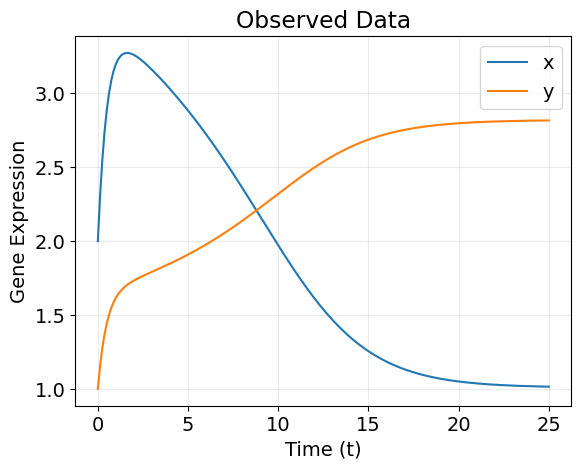

In [10]:
plt.plot(df.t,df.x, label="x")
plt.plot(df.t, df.y, label="y")
plt.xlabel("Time (t)")
plt.ylabel("Gene Expression")
plt.legend()
plt.title("Observed Data")


## PINNs solution

### Training data preparation


Min-max normalisation of time t and gene expression x, and y:
\begin{align}
\tilde{x} &= \frac{x - \min(x)}{\max(x) - \min(x)},\\
\tilde{y} &= \frac{y - \min(y)}{\max(y) - \min(y)},\\
\tau &= \frac{t - \min(t)}{\max(t) - \min(t)}.
\end{align}

In the code:

- Variables named as x/y : raw observed data
- Variables named as x_tilde/y_tilde : normalised version of raw observed data

In [12]:
## estimating normalisation parameters from data
def make_scalers(df):
    t0, t1 = df.t.min(), df.t.max()
    x_min, x_max = df.x.min(), df.x.max()
    y_min, y_max = df.y.min(), df.y.max()
    return {
        "t0": float(t0), "t1": float(t1), "T": float(t1 - t0),
        "x_min": float(x_min), "x_max": float(x_max), "x_range": float(x_max - x_min),
        "y_min": float(y_min), "y_max": float(y_max), "y_range": float(y_max - y_min),
    }

## function to perform min-max normalisation
def to_normalized(df, scalers):
    tau = ((df.t.values - scalers["t0"]) / scalers["T"]).reshape(-1, 1)
    x_tilde = ((df.x.values - scalers["x_min"]) / scalers["x_range"]).reshape(-1, 1)
    y_tilde = ((df.y.values - scalers["y_min"]) / scalers["y_range"]).reshape(-1, 1)
    return tau, np.hstack([x_tilde, y_tilde])


In [13]:
## sampling collocation points strategically on the basis of dynamics seen in observed data
def sample_collocation(n_pts, seed=0):
    rng = np.random.default_rng(seed)
    n1 = int(0.35 * n_pts) ## 35% in initial transient dynamics
    n2 = int(0.35 * n_pts) ## 35% in intermediate peak dynamics
    n3 = n_pts - n1 - n2 ## 30% in the tail dynamics
    c1 = rng.uniform(0.00, 0.08, n1)
    c2 = rng.uniform(0.08, 0.32, n2)
    c3 = rng.uniform(0.32, 1.00, n3)
    tau = np.sort(np.concatenate([c1, c2, c3])).reshape(-1, 1)
    return torch.tensor(tau, dtype=torch.float32)



In [14]:
torch.manual_seed(42)
device = torch.device("cpu")

## transforming the observation generate using numerical solution stored in df
scalers = make_scalers(df) 
tau_np, y_np = to_normalized(df, scalers)

## observed data points
tau_data = torch.tensor(tau_np, dtype=torch.float32, device=device)
y_data = torch.tensor(y_np, dtype=torch.float32, device=device)

## unobserved data points for evaluation of ODEs
tau_col = sample_collocation(6000, seed=42).to(device)

## extracting the initial values of x and y from the normalised data
x0_tilde = y_np[0, 0]
y0_tilde = y_np[0, 1]

### PINNs architecture with initial condition hard enforcement

In [11]:
## plain PINNs similar to the one used for one ODE system of logistic growth model
class VanillaPINN(nn.Module):
    def __init__(self, in_dim=1, out_dim=2, width=64, depth=4, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, width), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), activation()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

## PINNs with hard enforcment of the initial condition
class HardICPINN(nn.Module):
    def __init__(self, base_model, x0_tilde, y0_tilde):
        super().__init__()
        self.base = base_model
        self.register_buffer("x0_tilde", torch.tensor([[x0_tilde]], dtype=torch.float32))
        self.register_buffer("y0_tilde", torch.tensor([[y0_tilde]], dtype=torch.float32))

    def forward(self, tau):
        raw = self.base(tau) ## prediction using Vanilla PINNs
        x = self.x0_tilde + tau * raw[:, 0:1] ## initial condition application
        y = self.y0_tilde + tau * raw[:, 1:2] ## initial condition application
        return torch.cat([x, y], dim=1)


### ODE residual calculation

In [15]:
def ode_residuals(model, tau, params, scalers):
    tau = tau.clone().detach().requires_grad_(True)
    pred_tilde = model(tau)
    x_tilde = pred_tilde[:, 0:1]
    y_tilde = pred_tilde[:, 1:2]

    dxtilde_dtau = torch.autograd.grad(
        x_tilde, tau, grad_outputs=torch.ones_like(x_tilde), create_graph=True
    )[0]
    dytilde_dtau = torch.autograd.grad(
        y_tilde, tau, grad_outputs=torch.ones_like(y_tilde), create_graph=True
    )[0]

    ## model predictions are in normalised form, so bringing them to raw level for ODEs
    x = scalers["x_min"] + scalers["x_range"] * x_tilde
    y = scalers["y_min"] + scalers["y_range"] * y_tilde

    ## model predictions are in normalised form, so bringing them to raw level for ODEs
    dxdt = (scalers["x_range"] / scalers["T"]) * dxtilde_dtau
    dydt = (scalers["y_range"] / scalers["T"]) * dytilde_dtau

    ## estimating rhs of ODEs
    rhs_x = params["alpha_x"] / (1.0 + (y / params["K_y"]) ** params["n_y"]) - params["delta_x"] * x
    rhs_y = params["alpha_y"] / (1.0 + (x / params["K_x"]) ** params["n_x"]) - params["delta_y"] * y

    return dxdt - rhs_x, dydt - rhs_y ## ODE residual

### separate loss estimation for each components
1. Data
2. ODE for x
3. ODE for y

In [16]:
def evaluate_losses(model, tau_data, y_data, tau_col, params, scalers):
    with torch.enable_grad():
        pred = model(tau_data)
        data_loss = torch.mean((pred - y_data) ** 2)
        r1, r2 = ode_residuals(model, tau_col, params, scalers)
        ode_x_loss = torch.mean(r1 ** 2)
        ode_y_loss = torch.mean(r2 ** 2)
        ode_loss = ode_x_loss + ode_y_loss
    return data_loss, ode_x_loss, ode_y_loss, ode_loss

### Training PINNs in three stages
1. Only on observed data points
2. On observed data points and ODE with gradual increase in weight for ODE loss
3. Refining for data loss and ODE loss

Text(0, 0.5, 'Weight for ODE Loss')

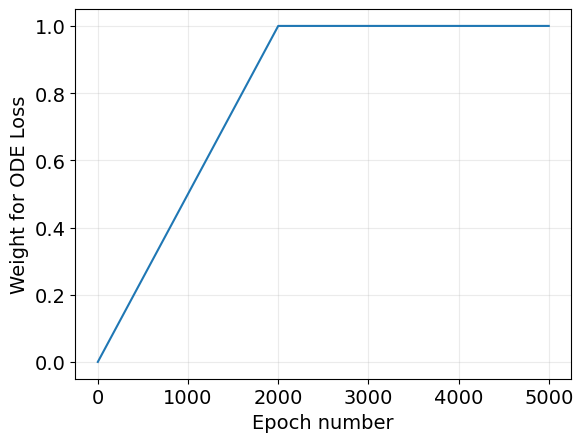

In [19]:
w_ode_ls = [min(1,(epoch + 1) / 2000) for epoch in range(5000)]
plt.plot(w_ode_ls)
plt.xlabel("Epoch number")
plt.ylabel("Weight for ODE Loss")

In [20]:
def train_pinn(
    model, tau_data, y_data, tau_col, params, scalers,
    adam_epochs_stage1=3000, adam_epochs_stage2=5000,
    lr=1e-3, ode_ramp_epochs=2000
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"data": [], "ode_x": [], "ode_y": [], "ode": [], "total": [], "w_ode": []}

    # Stage 1: data-only pretraining
    for epoch in range(adam_epochs_stage1):
        optimizer.zero_grad()
        pred = model(tau_data)
        data_loss = torch.mean((pred - y_data) ** 2)
        loss = data_loss
        loss.backward()
        optimizer.step()

        history["data"].append(float(data_loss.detach()))
        history["ode_x"].append(np.nan)
        history["ode_y"].append(np.nan)
        history["ode"].append(np.nan)
        history["total"].append(float(loss.detach()))
        history["w_ode"].append(0.0)

    # Stage 2: add ODE gradually
    for epoch in range(adam_epochs_stage2):
        optimizer.zero_grad()
        data_loss, ode_x_loss, ode_y_loss, ode_loss = evaluate_losses(
            model, tau_data, y_data, tau_col, params, scalers
        )
        w_ode = min(1.0, (epoch + 1) / ode_ramp_epochs) ## weight of ode loss increases gradually but remains below 1
        loss = data_loss + w_ode * ode_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) ## gradient clipping to prevent large update in NN parameter
        optimizer.step()

        history["data"].append(float(data_loss.detach()))
        history["ode_x"].append(float(ode_x_loss.detach()))
        history["ode_y"].append(float(ode_y_loss.detach()))
        history["ode"].append(float(ode_loss.detach()))
        history["total"].append(float(loss.detach()))
        history["w_ode"].append(float(w_ode))

    # Stage 3: L-BFGS refinement
    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=0.5,
        max_iter=300,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        line_search_fn="strong_wolfe",
    )

    def closure():
        lbfgs.zero_grad()
        data_loss, _, _, ode_loss = evaluate_losses(model, tau_data, y_data, tau_col, params, scalers)
        loss = data_loss + ode_loss
        loss.backward()
        return loss

    lbfgs.step(closure)

    data_loss, ode_x_loss, ode_y_loss, ode_loss = evaluate_losses(
        model, tau_data, y_data, tau_col, params, scalers
    )
    total = data_loss + ode_loss
    history["data"].append(float(data_loss.detach()))
    history["ode_x"].append(float(ode_x_loss.detach()))
    history["ode_y"].append(float(ode_y_loss.detach()))
    history["ode"].append(float(ode_loss.detach()))
    history["total"].append(float(total.detach()))
    history["w_ode"].append(1.0)

    return history

### function to plot loss curves and the actual vs predicted comparison

In [ ]:
def plot_results(df, pred_df, history):
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(df["t"], df["x"], "-", lw=2.5, color="royalblue", label="Observations (x_actual)", marker='o',markersize=10)
    ax.plot(df["t"], df["y"], "-", lw=2.5, color="orange", label="Observations (y_actual)", marker='o',markersize=10)
    ax.plot(pred_df["t"], pred_df["x_pred"], "-", lw=2.5, color="blue", label="PINN Prediction (x_predicted)")
    ax.plot(pred_df["t"], pred_df["y_pred"], "-", lw=2.5, color="darkorange", label="PINN Prediction (y_predicted)")
    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Gene Expression")
    ax.legend(frameon=True)
    fig.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    axs[0].plot(history["data"])
    axs[0].set_title("data")
    axs[1].plot([v for v in history["ode_x"] if not np.isnan(v)])
    axs[1].set_title("ode_x")
    axs[2].plot([v for v in history["ode_y"] if not np.isnan(v)])
    axs[2].set_title("ode_y")
    axs[3].plot(history["total"])
    axs[3].set_title("total_loss")
    for ax in axs:
        ax.set_xlabel("Epoch/step")
        ax.set_ylabel("Loss")
    fig.tight_layout()
    plt.show()

In [21]:
## function to bring back the normalised prediction to raw level
def unscale_states(pred_tilde, scalers):
    x = scalers["x_min"] + scalers["x_range"] * pred_tilde[:, 0:1]
    y = scalers["y_min"] + scalers["y_range"] * pred_tilde[:, 1:2]
    return x, y

### Fitting PINNs

In [ ]:

model = HardICPINN(
    VanillaPINN(in_dim=1, out_dim=2, width=64, depth=4, activation=nn.Tanh),
    x0_tilde,
    y0_tilde,
).to(device)

history = train_pinn(model, tau_data, y_data, tau_col, params, scalers)

with torch.no_grad():
    pred_tilde = model(tau_data).cpu().numpy()

x_pred, y_pred = unscale_states(pred_tilde, scalers)

pred_df = pd.DataFrame({
    "t": df["t"].values,
    "x_actual": df["x"].values,
    "y_actual": df["y"].values,
    "x_pred": x_pred.ravel(),
    "y_pred": y_pred.ravel(),
})



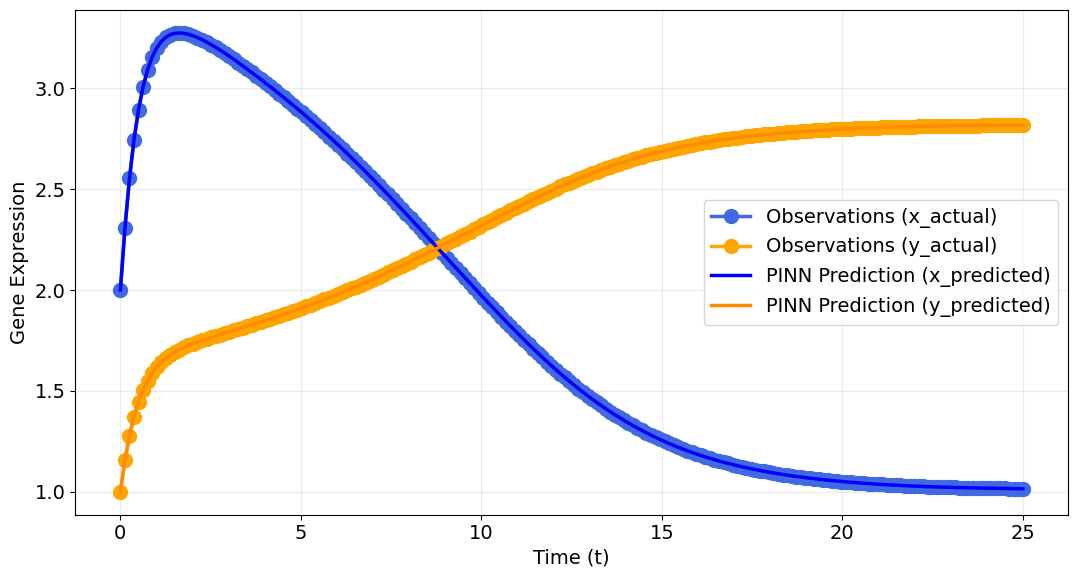

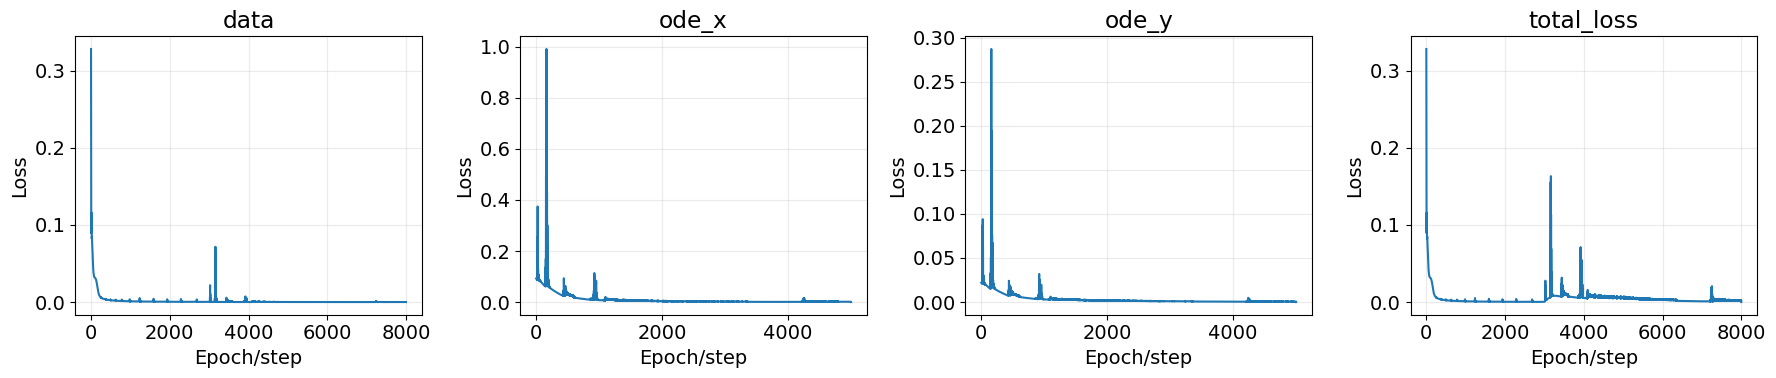

In [30]:
plot_results(df, pred_df, history)